Dataset loaded from: /content/dataset.csv
Dataset shape: (1734, 13)

DATASET INFORMATION
Samples  : 1734
Features : 10
Classes  : 18
Target   : AzSector

Feature columns:
  - TX_TDOA
  - TY_TDOA
  - Diagonal_TDOA_1
  - Diagonal_TDOA_2
  - MUSIC_Az
  - GCC_Az
  - ILD_dB
  - RMS_mean
  - FFT_PeakFreq
  - SpecEntropyNorm

Class distribution:
Az_-90to-80    97
Az_-80to-70    98
Az_-70to-60    96
Az_-60to-50    97
Az_-50to-40    97
Az_-40to-30    97
Az_-30to-20    97
Az_-20to-10    99
Az_-10to0      98
Az_0to10       94
Az_10to20      96
Az_20to30      92
Az_30to40      96
Az_40to50      96
Az_50to60      95
Az_60to70      99
Az_70to80      96
Az_80to90      94
Name: count, dtype: int64

TRAIN / TEST SPLIT
Training samples : 1300
Testing samples  : 434

SVM - GRID SEARCH
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best SVM parameters:
{'svc__C': 100, 'svc__kernel': 'linear'}
Best SVM CV accuracy: 0.9454
SVM held-out test accuracy: 0.9654

RANDOM FOREST - GRID SEARCH
Fitti

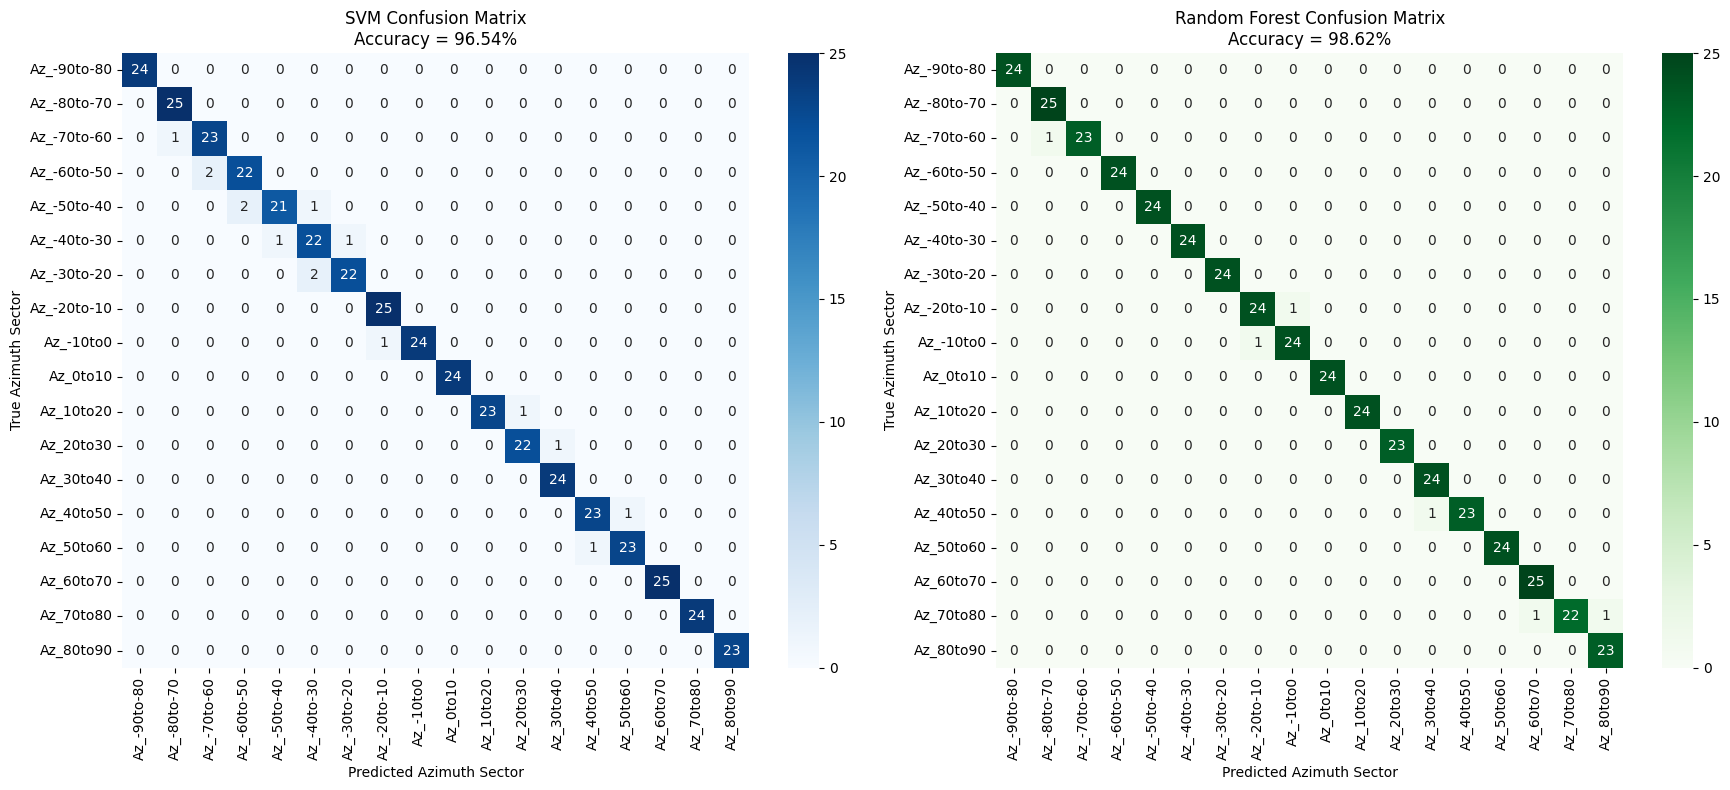

Saved: confusion_matrices.png


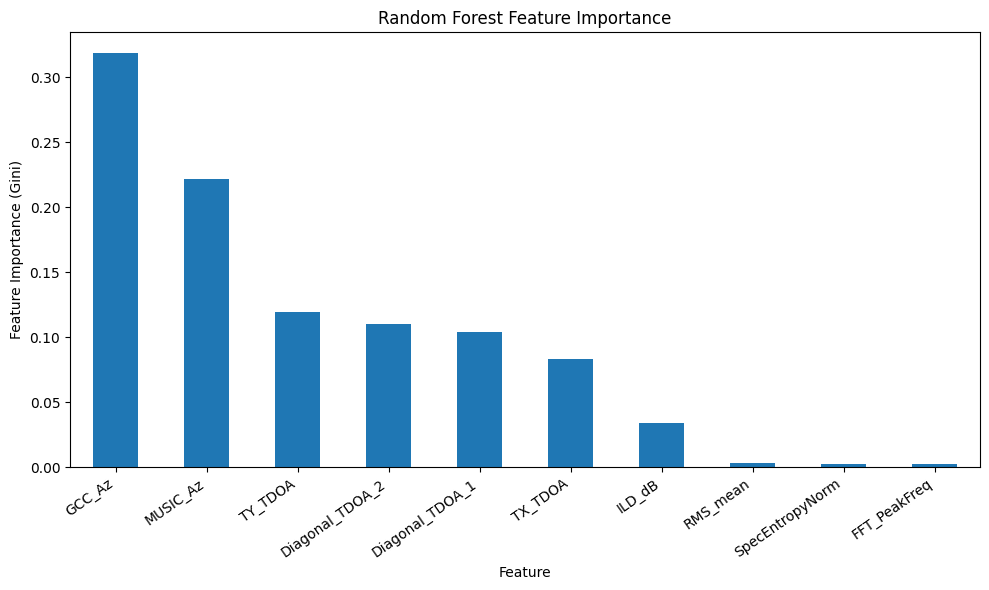


FEATURE IMPORTANCE
GCC_Az             0.318516
MUSIC_Az           0.221900
TY_TDOA            0.119626
Diagonal_TDOA_2    0.110229
Diagonal_TDOA_1    0.104250
TX_TDOA            0.082815
ILD_dB             0.034032
RMS_mean           0.003182
SpecEntropyNorm    0.002741
FFT_PeakFreq       0.002709
dtype: float64

Saved: feature_importance.png

MODEL SUMMARY
        Model  Best_CV_Accuracy  Heldout_Test_Accuracy
          SVM          0.945385               0.965438
Random Forest          0.983846               0.986175

Saved:
  svm_model.joblib
  rf_model.joblib


In [ ]:
"""
train_classifier.py
-------------------

SVM and Random Forest classifiers for azimuth-sector classification
using features generated by the MATLAB acoustic DOA pipeline.

The MATLAB dataset contains:
    TX_TDOA
    TY_TDOA
    Diagonal_TDOA_1
    Diagonal_TDOA_2
    MUSIC_Az
    GCC_Az
    ILD_dB
    RMS_mean
    FFT_PeakFreq
    SpecEntropyNorm

Target:
    AzSector   -> 18 azimuth classes
                  (-90 to +90 degrees, 10-degree sectors)

The script performs:
    1. Dataset loading
    2. Feature validation
    3. Train/test split
    4. SVM hyperparameter tuning using GridSearchCV
    5. Random Forest hyperparameter tuning
    6. Cross-validation accuracy
    7. Held-out test evaluation
    8. Classification reports
    9. Confusion matrices
   10. Random Forest feature importance
   11. Model saving with joblib
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------

# Change this to the location of your dataset.
DATA_PATH = "/content/dataset.csv"

# Classification target.
TARGET_COLUMN = "AzSector"

# Reproducibility.
RANDOM_STATE = 42

# 25% of the data is kept completely separate for final evaluation.
TEST_SIZE = 0.25

# 5-fold stratified cross-validation.
CV_FOLDS = 5


# ----------------------------------------------------------------------
# Features generated by the new MATLAB pipeline
# ----------------------------------------------------------------------

FEATURE_COLUMNS = [
    "TX_TDOA",
    "TY_TDOA",
    "Diagonal_TDOA_1",
    "Diagonal_TDOA_2",
    "MUSIC_Az",
    "GCC_Az",
    "ILD_dB",
    "RMS_mean",
    "FFT_PeakFreq",
    "SpecEntropyNorm",
]


# ----------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------

def parse_numeric(value):
    """
    Convert a CSV value to a real-valued float.

    MATLAB may export some signal-derived values as strings containing
    complex numbers. For compatibility, those values are parsed and
    converted to magnitude.

    Ideally, ILD and RMS should already be real-valued in the MATLAB
    pipeline. This function simply makes the Python loader robust to
    older CSV files.
    """

    if pd.isna(value):
        return np.nan

    s = str(value).strip()

    # Handle MATLAB-style complex numbers.
    if "i" in s or "j" in s:

        s = s.replace("i", "j")

        try:
            return abs(complex(s))
        except ValueError:
            return np.nan

    try:
        return float(s)

    except ValueError:
        return np.nan


def order_azimuth_classes(class_names):
    """
    Order classes according to their numerical azimuth boundary.

    Example:
        Az_-90to-80
        Az_-80to-70
        ...
        Az_80to90

    This prevents lexicographic sorting from producing an incorrect
    confusion-matrix ordering.
    """

    def lower_bound(name):
        try:
            return float(
                name.replace("Az_", "").split("to")[0]
            )
        except (ValueError, IndexError):
            return 9999

    return sorted(class_names, key=lower_bound)


def load_dataset(path, target_column):
    """
    Load and validate the MATLAB-generated dataset.
    """

    df = pd.read_csv(path)

    print(f"Dataset loaded from: {path}")
    print(f"Dataset shape: {df.shape}")

    # --------------------------------------------------------------
    # Check required columns
    # --------------------------------------------------------------

    required_columns = FEATURE_COLUMNS + [target_column]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            "The following required columns are missing from the dataset:\n"
            + "\n".join(missing_columns)
        )

    # --------------------------------------------------------------
    # Convert feature columns to numeric values
    # --------------------------------------------------------------

    for col in FEATURE_COLUMNS:
        df[col] = df[col].apply(parse_numeric)

    # --------------------------------------------------------------
    # Remove rows containing invalid feature values
    # --------------------------------------------------------------

    before = len(df)

    df = df.dropna(
        subset=FEATURE_COLUMNS + [target_column]
    ).reset_index(drop=True)

    removed = before - len(df)

    if removed > 0:
        print(f"Removed {removed} rows containing invalid values.")

    # --------------------------------------------------------------
    # Extract X and y
    # --------------------------------------------------------------

    X = df[FEATURE_COLUMNS].to_numpy(dtype=float)

    y = df[target_column].astype(str).to_numpy()

    return X, y, df


# ----------------------------------------------------------------------
# Load dataset
# ----------------------------------------------------------------------

X, y, df = load_dataset(
    DATA_PATH,
    TARGET_COLUMN
)

class_names = order_azimuth_classes(
    pd.unique(y).tolist()
)

print()
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(
    f"Samples  : {X.shape[0]}"
)

print(
    f"Features : {X.shape[1]}"
)

print(
    f"Classes  : {len(class_names)}"
)

print(
    f"Target   : {TARGET_COLUMN}"
)

print()

print("Feature columns:")
for feature in FEATURE_COLUMNS:
    print(f"  - {feature}")

print()

print("Class distribution:")
print(
    pd.Series(y)
    .value_counts()
    .reindex(class_names)
)

print()


# ----------------------------------------------------------------------
# Train / Test split
# ----------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print()


# ----------------------------------------------------------------------
# Cross-validation configuration
# ----------------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ======================================================================
# SVM
# ======================================================================

print("=" * 70)
print("SVM - GRID SEARCH")
print("=" * 70)


# Scaling is important because the features have very different
# numerical ranges:
#
#   TDOA             -> approximately 1e-5
#   MUSIC_Az         -> degrees
#   FFT_PeakFreq     -> hundreds/thousands
#   RMS              -> small amplitude
#
# StandardScaler puts them on a comparable scale.

svm_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "svc",
        SVC(
            decision_function_shape="ovr",
            random_state=RANDOM_STATE
        )
    )
])


# ----------------------------------------------------------------------
# SVM parameter grid
# ----------------------------------------------------------------------
#
# A separate dictionary is used for each kernel because not every
# kernel uses the same hyperparameters.
#
# Linear:
#     C
#
# RBF:
#     C
#     gamma
#
# Polynomial:
#     C
#     gamma
#     degree
#     coef0
#
# Sigmoid:
#     C
#     gamma
#     coef0

svm_param_grid = [

    # --------------------------------------------------------------
    # Linear kernel
    # --------------------------------------------------------------

    {
        "svc__kernel": ["linear"],

        "svc__C": [
            0.1,
            1,
            10,
            100
        ]
    },


    # --------------------------------------------------------------
    # RBF kernel
    # --------------------------------------------------------------

    {
        "svc__kernel": ["rbf"],

        "svc__C": [
            0.1,
            1,
            10,
            100
        ],

        "svc__gamma": [
            "scale",
            0.001,
            0.01,
            0.1,
            1
        ]
    },


    # --------------------------------------------------------------
    # Polynomial kernel
    # --------------------------------------------------------------

    {
        "svc__kernel": ["poly"],

        "svc__C": [
            0.1,
            1,
            10
        ],

        "svc__gamma": [
            "scale",
            0.001,
            0.01,
            0.1
        ],

        "svc__degree": [
            2,
            3
        ],

        "svc__coef0": [
            0,
            1
        ]
    },


    # --------------------------------------------------------------
    # Sigmoid kernel
    # --------------------------------------------------------------

    {
        "svc__kernel": ["sigmoid"],

        "svc__C": [
            0.1,
            1,
            10
        ],

        "svc__gamma": [
            "scale",
            0.001,
            0.01,
            0.1
        ],

        "svc__coef0": [
            0,
            1
        ]
    }
]


# ----------------------------------------------------------------------
# SVM Grid Search
# ----------------------------------------------------------------------

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(
    X_train,
    y_train
)


# ----------------------------------------------------------------------
# SVM results
# ----------------------------------------------------------------------

print()
print("Best SVM parameters:")
print(svm_grid.best_params_)

print(
    f"Best SVM CV accuracy: "
    f"{svm_grid.best_score_:.4f}"
)

svm_best = svm_grid.best_estimator_

y_pred_svm = svm_best.predict(X_test)

svm_test_acc = accuracy_score(
    y_test,
    y_pred_svm
)

print(
    f"SVM held-out test accuracy: "
    f"{svm_test_acc:.4f}"
)

print()


# ======================================================================
# RANDOM FOREST
# ======================================================================

print("=" * 70)
print("RANDOM FOREST - GRID SEARCH")
print("=" * 70)


# Random Forest does not require feature scaling.
#
# bootstrap=True is kept because it is required for OOB estimation.
# Out-of-bag scoring provides an additional validation estimate using
# samples not included in the bootstrap sample of individual trees.
# ----------------------------------------------------------------------

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    bootstrap=True,
    n_jobs=-1
)


rf_param_grid = {

    "n_estimators": [
        100,
        200,
        400
    ],

    "max_depth": [
        None,
        10,
        20
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        "log2"
    ]
}


# ----------------------------------------------------------------------
# Random Forest Grid Search
# ----------------------------------------------------------------------

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train,
    y_train
)


print()
print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print(
    f"Best RF CV accuracy: "
    f"{rf_grid.best_score_:.4f}"
)


# ----------------------------------------------------------------------
# Refit best RF with OOB scoring
# ----------------------------------------------------------------------

rf_best = RandomForestClassifier(
    **rf_grid.best_params_,
    random_state=RANDOM_STATE,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1
)

rf_best.fit(
    X_train,
    y_train
)


y_pred_rf = rf_best.predict(
    X_test
)

rf_test_acc = accuracy_score(
    y_test,
    y_pred_rf
)


print(
    f"RF OOB accuracy: "
    f"{rf_best.oob_score_:.4f}"
)

print(
    f"RF held-out test accuracy: "
    f"{rf_test_acc:.4f}"
)

print()


# ======================================================================
# CLASSIFICATION REPORTS
# ======================================================================

print("=" * 70)
print("SVM CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_svm,
        labels=class_names,
        zero_division=0
    )
)


print("=" * 70)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=class_names,
        zero_division=0
    )
)


# ======================================================================
# CONFUSION MATRICES
# ======================================================================

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=class_names
)

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=class_names
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)


# ----------------------------------------------------------------------
# SVM confusion matrix
# ----------------------------------------------------------------------

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title(
    f"SVM Confusion Matrix\n"
    f"Accuracy = {svm_test_acc * 100:.2f}%"
)

axes[0].set_xlabel("Predicted Azimuth Sector")
axes[0].set_ylabel("True Azimuth Sector")

axes[0].tick_params(
    axis="x",
    rotation=90
)


# ----------------------------------------------------------------------
# Random Forest confusion matrix
# ----------------------------------------------------------------------

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)

axes[1].set_title(
    f"Random Forest Confusion Matrix\n"
    f"Accuracy = {rf_test_acc * 100:.2f}%"
)

axes[1].set_xlabel("Predicted Azimuth Sector")
axes[1].set_ylabel("True Azimuth Sector")

axes[1].tick_params(
    axis="x",
    rotation=90
)


plt.tight_layout()

plt.savefig(
    "confusion_matrices.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: confusion_matrices.png")


# ======================================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ======================================================================

importances = pd.Series(
    rf_best.feature_importances_,
    index=FEATURE_COLUMNS
)

importances = importances.sort_values(
    ascending=False
)


plt.figure(
    figsize=(10, 6)
)

importances.plot(
    kind="bar"
)

plt.ylabel(
    "Feature Importance (Gini)"
)

plt.xlabel(
    "Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print()
print("=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(
    importances
)

print()
print("Saved: feature_importance.png")


# ======================================================================
# MODEL SUMMARY
# ======================================================================

summary = pd.DataFrame({

    "Model": [
        "SVM",
        "Random Forest"
    ],

    "Best_CV_Accuracy": [
        svm_grid.best_score_,
        rf_grid.best_score_
    ],

    "Heldout_Test_Accuracy": [
        svm_test_acc,
        rf_test_acc
    ]
})


print()
print("=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

print(
    summary.to_string(index=False)
)


# ======================================================================
# Save models
# ======================================================================

joblib.dump(
    svm_best,
    "svm_model.joblib"
)

joblib.dump(
    rf_best,
    "rf_model.joblib"
)


print()
print("Saved:")
print("  svm_model.joblib")
print("  rf_model.joblib")

Stacked model held-out test accuracy: 0.9885

Stacked Model Classification Report
              precision    recall  f1-score   support

 Az_-90to-80       1.00      1.00      1.00        24
 Az_-80to-70       0.96      1.00      0.98        25
 Az_-70to-60       1.00      0.96      0.98        24
 Az_-60to-50       1.00      1.00      1.00        24
 Az_-50to-40       1.00      1.00      1.00        24
 Az_-40to-30       1.00      1.00      1.00        24
 Az_-30to-20       1.00      1.00      1.00        24
 Az_-20to-10       0.96      0.96      0.96        25
   Az_-10to0       0.96      0.96      0.96        25
    Az_0to10       1.00      1.00      1.00        24
   Az_10to20       1.00      1.00      1.00        24
   Az_20to30       1.00      1.00      1.00        23
   Az_30to40       0.96      1.00      0.98        24
   Az_40to50       1.00      0.96      0.98        24
   Az_50to60       1.00      1.00      1.00        24
   Az_60to70       1.00      1.00      1.00        25

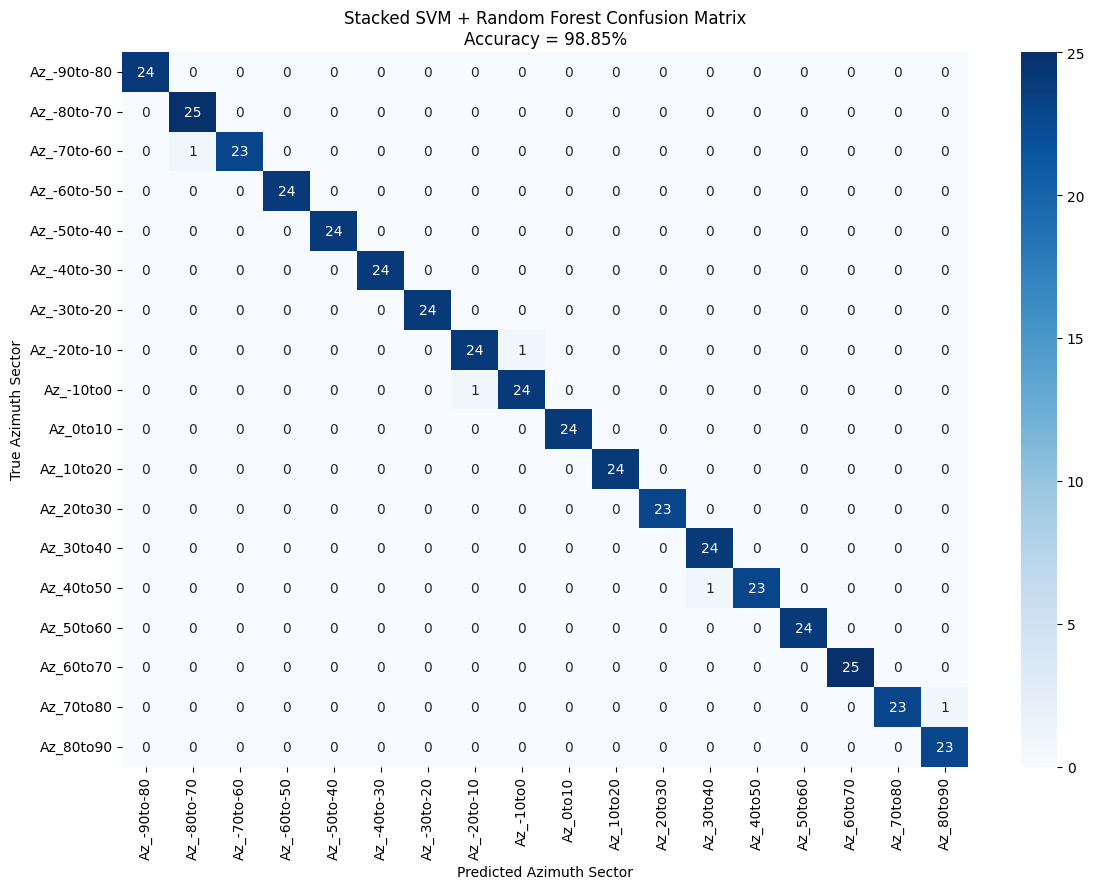

Saved stacked_confusion_matrix.png
Saved stacked_model.joblib


In [3]:
"""
build_stacked_model.py
-----------------------
Combines the tuned SVM and Random Forest classifiers into a single
StackingClassifier, using a logistic regression meta-learner trained
on both models' outputs via internal cross-validation.

Requires: dataset.csv (with TX_TDOA, TY_TDOA, Diagonal_TDOA_1/2,
MUSIC_Az, GCC_Az, ILD_dB, RMS_mean, FFT_PeakFreq, SpecEntropyNorm,
AzSector columns) in the same directory.
"""

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
TEST_SIZE = 0.25
TARGET_COLUMN = "AzSector"
FEATURE_COLUMNS = [
    "TX_TDOA", "TY_TDOA", "Diagonal_TDOA_1", "Diagonal_TDOA_2",
    "MUSIC_Az", "GCC_Az", "ILD_dB", "RMS_mean", "FFT_PeakFreq", "SpecEntropyNorm",
]


def parse_numeric(value):
    """Handles MATLAB-exported complex-valued ILD_dB/RMS_mean strings
    (a known artifact of squaring complex baseband signals upstream) by
    taking their magnitude. Real-valued strings pass through unchanged."""
    s = str(value).strip()
    if "i" in s or "j" in s:
        try:
            return abs(complex(s.replace("i", "j")))
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def load_dataset(path):
    df = pd.read_csv(path)
    for col in ["ILD_dB", "RMS_mean"]:
        df[col] = df[col].apply(parse_numeric)
    df = df.dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN]).reset_index(drop=True)
    X = df[FEATURE_COLUMNS].to_numpy(dtype=float)
    y = df[TARGET_COLUMN].astype(str).to_numpy()
    return X, y


X, y = load_dataset("/content/dataset.csv")
class_names = sorted(pd.unique(y).tolist(),
                      key=lambda s: float(s.replace("Az_", "").split("to")[0]))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Base learners, using the same tuned hyperparameters found earlier.
# probability=True is required so soft-voting/stacking can use SVM's
# predicted probabilities, not just hard labels.
svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(C=100, kernel="linear", probability=True, random_state=RANDOM_STATE)),
])
rf_base = RandomForestClassifier(
    n_estimators=100, max_depth=None, max_features="sqrt",
    min_samples_leaf=1, random_state=RANDOM_STATE, n_jobs=-1,
)

stacked_model = StackingClassifier(
    estimators=[("svm", svm_base), ("rf", rf_base)],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=cv,
)
stacked_model.fit(X_train, y_train)

# ----------------------------------------------------------------------
# Evaluation
# ----------------------------------------------------------------------

y_pred = stacked_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Stacked model held-out test accuracy: {acc:.4f}")
print()

print("=" * 60)
print("Stacked Model Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        labels=class_names,
        zero_division=0
    )
)


# ----------------------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    f"Stacked SVM + Random Forest Confusion Matrix\n"
    f"Accuracy = {acc * 100:.2f}%"
)

plt.xlabel("Predicted Azimuth Sector")
plt.ylabel("True Azimuth Sector")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "stacked_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved stacked_confusion_matrix.png")


# ----------------------------------------------------------------------
# Save model
# ----------------------------------------------------------------------

joblib.dump(
    stacked_model,
    "stacked_model.joblib"
)

print("Saved stacked_model.joblib")